# PERSIAPAN

## Impor library

In [1]:
import numpy as np
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

2025-07-15 11:56:20.126668: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752580580.523188      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752580580.633306      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Membuat fungsi utilitas logging

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] - %(message)s',
    handlers=[
        logging.FileHandler("log_preprocessing_dataset.log", mode='w'), # Simpan log ke file
        logging.StreamHandler() # Tampilkan juga di layar
    ]
)

# Dapatkan instance logger untuk digunakan di seluruh skrip
logger = logging.getLogger(__name__)

logger.info("Sistem logging siap digunakan.")

# Langkah 1: Memuat Gambar

## Mengubah ukuran gambar supaya muat kedalam model

In [3]:
UKURAN_TARGET_RAW = (224, 224)
path_dataset_utama = "/kaggle/input/dataset-no-process"

## Membuat fungsi pemrosesan gambar

In [4]:
def proses_gambar(path_dataset_utama):
    X_raw_data = []
    y_raw_labels = []
    print("Memulai pemrosesan gambar mentah...")
    for nama_kategori in sorted(os.listdir(path_dataset_utama)):
        path_kategori = os.path.join(path_dataset_utama, nama_kategori)
        if os.path.isdir(path_kategori):
            print(f"Memproses kategori: {nama_kategori}")
            for nama_file in os.listdir(path_kategori):
                path_file_gambar = os.path.join(path_kategori, nama_file)
                
                # Muat gambar mentah
                gambar = cv2.imread(path_file_gambar)
                if gambar is not None:
                    # Resize gambar langsung ke ukuran target
                    gambar_resized = cv2.resize(gambar, UKURAN_TARGET_RAW, interpolation=cv2.INTER_AREA)
                    X_raw_data.append(gambar_resized)
                    y_raw_labels.append(nama_kategori)

    return X_raw_data, y_raw_labels
    
    print("\nDataset mentah selesai diproses.")

In [5]:
X_raw_data, y_raw_labels = proses_gambar(path_dataset_utama)
# print(f'raw data: {X_raw_data} dan raw labels: {y_raw_labels}')

Memulai pemrosesan gambar mentah...
Memproses kategori: abnormal
Memproses kategori: history_myocardial_infaction
Memproses kategori: myocardial_infarction
Memproses kategori: normal


## Membuat fungsi persiapan pelatihan

In [6]:
def siapkan_dataset_untuk_pelatihan(data, label):
    # Konversi ke NumPy array
    X = np.array(data)
    y_str = np.array(label)
    
    # Normalisasi piksel ke rentang [0, 1]
    X = X / 255.0
    
    # Encode label dan bagi data
    encoder = LabelEncoder()
    y = encoder.fit_transform(y_str)
    NUM_CLASSES = len(encoder.classes_)
    return X, y, NUM_CLASSES, encoder

In [7]:
X, y, NUM_CLASSES, encoder = siapkan_dataset_untuk_pelatihan(X_raw_data, y_raw_labels)
# print(f'Z: {X} dan y: {y} dan jumlah kelas: {NUM_CLASSES}')

## Pembagian data

In [8]:
def pembagian_data(data, label):
    print("Membagi data menjadi 80% (latih+validasi) dan 20% (tes)...")
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        data, label, 
        test_size=0.20,  # 20% dari data keseluruhan untuk testing
        random_state=42, # Agar hasil pembagian selalu konsisten
        stratify=y       # Menjaga proporsi kelas tetap seimbang
    )

    print("Membagi kumpulan data latih menjadi data latih final dan data validasi...")
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, 
        test_size=0.20,  # 20% dari data X_train_val untuk validasi
        random_state=42, # Gunakan random_state yang sama untuk konsistensi
        stratify=y_train_val # Lakukan stratify juga pada pembagian kedua
    )

    return X_train, y_train, X_test, y_test, X_val, y_val

In [9]:
X_train, y_train, X_test, y_test, X_val, y_val = pembagian_data(X, y)
# --- Verifikasi Hasil Akhir ---
print("\n--- UKURAN DATASET FINAL ---")
print(f"Jumlah Data Latih (Train)        : {len(y_train)} sampel (~{len(y_train)/len(y)*100:.0f}%)")
print(f"Jumlah Data Validasi (Validation): {len(y_val)} sampel (~{len(y_val)/len(y)*100:.0f}%)")
print(f"Jumlah Data Tes (Test)           : {len(y_test)} sampel (~{len(y_test)/len(y)*100:.0f}%)")
print("--------------------------------")
print(f"Total Sampel                     : {len(y_train) + len(y_val) + len(y_test)}")

Membagi data menjadi 80% (latih+validasi) dan 20% (tes)...
Membagi kumpulan data latih menjadi data latih final dan data validasi...

--- UKURAN DATASET FINAL ---
Jumlah Data Latih (Train)        : 593 sampel (~64%)
Jumlah Data Validasi (Validation): 149 sampel (~16%)
Jumlah Data Tes (Test)           : 186 sampel (~20%)
--------------------------------
Total Sampel                     : 928


# Langkah 2: Membuat model

## Membuat fungsi model mobile net v2

In [10]:
# --- LANGKAH 2: BUAT MODEL MOBILENET ---
def create_raw_mobilenet(input_shape, num_classes):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False
    
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    return model

## Debug summary model

In [11]:
# Buat model
raw_model = create_raw_mobilenet(UKURAN_TARGET_RAW + (3,), NUM_CLASSES)
raw_model.summary()

I0000 00:00:1752580648.111974      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1752580648.112639      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │           5,124 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Kompilasi dan latih

In [12]:
raw_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=1,
    restore_best_weights=True
);


print("\nMemulai pelatihan pada gambar mentah...")
history = raw_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[early_stopping_callback]
)


Memulai pelatihan pada gambar mentah...
Epoch 1/50


I0000 00:00:1752580658.259274      60 service.cc:148] XLA service 0x7d96741107b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752580658.260858      60 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1752580658.260882      60 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1752580659.138935      60 cuda_dnn.cc:529] Loaded cuDNN version 90300


 5/19 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2592 - loss: 1.7964

I0000 00:00:1752580664.506960      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 612ms/step - accuracy: 0.2572 - loss: 1.7553 - val_accuracy: 0.2685 - val_loss: 1.4587
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2488 - loss: 1.5828 - val_accuracy: 0.3020 - val_loss: 1.3212
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2848 - loss: 1.4505 - val_accuracy: 0.4832 - val_loss: 1.2668
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3283 - loss: 1.4015 - val_accuracy: 0.5369 - val_loss: 1.2285
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.3710 - loss: 1.4129 - val_accuracy: 0.6107 - val_loss: 1.1946
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4257 - loss: 1.2999 - val_accuracy: 0.5906 - val_loss: 1.1652
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4118 - loss: 1.2790 - val_accuracy: 0.6309 - val_loss: 1.1376
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4152 - loss: 1.2642 - val_accuracy: 0.6242 - val_loss: 

# Langkah 3: Evaluasi

## Menggunakan confusion matrix

In [13]:
def prediksi(model, data_tes, label_tes):
    y_pred_probs = model.predict(data_tes)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    data_confusion_matrix = confusion_matrix(label_tes, y_pred_classes)

    return data_confusion_matrix, y_pred_classes

In [14]:
def simpan_laporan_kinerja(history, model, X_test, y_test, nama_model, folder_tujuan='hasil_evaluasi'):
    try:
        print(f"\n--- Membuat Laporan Kinerja untuk: {nama_model} ---")

        # --- LANGKAH 1: EKSTRAK METRIK DARI DATA VALIDASI ---
        val_accuracy_terbaik = np.max(history.history['val_accuracy'])
        val_loss_terbaik = np.min(history.history['val_loss'])
        epoch_terbaik = np.argmin(history.history['val_loss']) + 1

        # --- LANGKAH 2: EVALUASI PADA DATA TES ---
        loss_tes, akurasi_tes = model.evaluate(X_test, y_test, verbose=0)

        # --- LANGKAH 3: BUAT STRING LAPORAN LENGKAP ---
        laporan_teks = (
            f"Laporan Kinerja Model: {nama_model}\n"
            f"================================================\n\n"
            f"METRIK PADA DATA VALIDASI (selama pelatihan):\n"
            f"--------------------------------------------\n"
            f"Akurasi Validasi Tertinggi: {val_accuracy_terbaik:.4f}\n"
            f"Loss Validasi Terendah    : {val_loss_terbaik:.4f}\n"
            f"Dicapai pada Epoch          : {epoch_terbaik}\n\n"
            f"METRIK PADA DATA TES (evaluasi akhir):\n"
            f"----------------------------------------\n"
            f"Akurasi Tes Final: {akurasi_tes:.4f}\n"
            f"Loss Tes Final   : {loss_tes:.4f}\n"
        )
        
        # Cetak laporan ke konsol
        print(laporan_teks)

        # --- LANGKAH 4: SIMPAN LAPORAN KE FILE ---
        # Pastikan folder ada
        os.makedirs(folder_tujuan, exist_ok=True)
        
        # Buat nama file yang unik
        nama_file_output = f'kinerja_{nama_model.lower()}.txt'
        path_lengkap = os.path.join(folder_tujuan, nama_file_output)
        
        # Tulis ke file
        with open(path_lengkap, 'w') as f:
            f.write(laporan_teks)
            
        print(f"\n✅ Laporan kinerja telah disimpan di: '{path_lengkap}'")

    except Exception as e:
        print(f"❌ Terjadi error saat membuat laporan kinerja: {e}")



In [15]:
print("\nEvaluasi akhir:")
cm, y_pred_classes = prediksi(raw_model, X_test, y_test)


Evaluasi akhir:
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 982ms/step


In [16]:
simpan_laporan_kinerja(
    history=history,
    model=raw_model, # Gunakan variabel model yang baru saja dilatih
    X_test=[X_test], # Berikan data tes dalam bentuk list
    y_test=y_test, # Label tes
    nama_model='MobileNetV2 Raw', # Beri nama yang jelas
)


--- Membuat Laporan Kinerja untuk: MobileNetV2 Raw ---


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_154
Received: inputs=('Tensor(shape=(None, 224, 224, 3))',)
  warnings.warn(msg)


Laporan Kinerja Model: MobileNetV2 Raw

METRIK PADA DATA VALIDASI (selama pelatihan):
--------------------------------------------
Akurasi Validasi Tertinggi: 0.7248
Loss Validasi Terendah    : 0.7372
Dicapai pada Epoch          : 50

METRIK PADA DATA TES (evaluasi akhir):
----------------------------------------
Akurasi Tes Final: 0.7957
Loss Tes Final   : 0.6847


✅ Laporan kinerja telah disimpan di: 'hasil_evaluasi/kinerja_mobilenetv2 raw.txt'


In [17]:
def menampilkan_dan_menyimpan_confusion_matrix(cm):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title('Confusion Matrix - Model pada Gambar Mentah - MobileNetV2')
    plt.ylabel('Kelas Asli (True Label)')
    plt.xlabel('Kelas Prediksi (Predicted Label)')
    
    nama_file_output = 'confusion_matrix_mobilenet_raw.png'
    plt.savefig(nama_file_output, dpi=300, bbox_inches='tight')
    print(f"\nPlot confusion matrix telah disimpan sebagai: '{nama_file_output}'")
    
    plt.show()


Plot confusion matrix telah disimpan sebagai: 'confusion_matrix_mobilenet_raw.png'


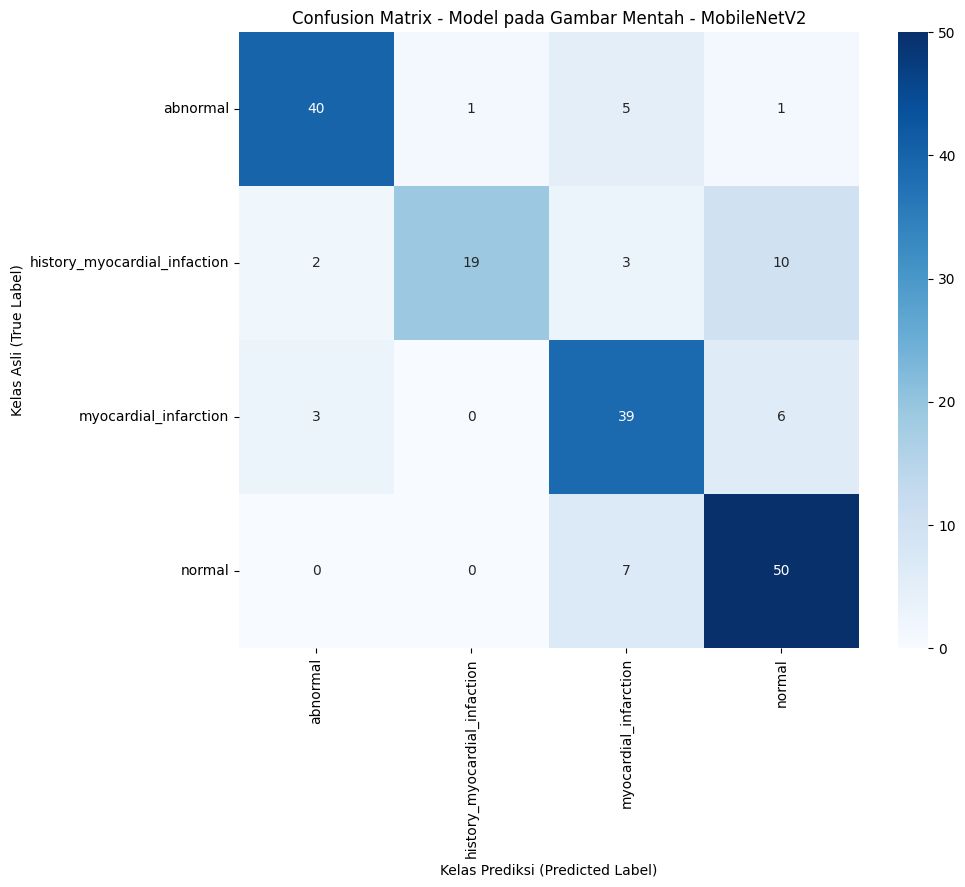

In [18]:
menampilkan_dan_menyimpan_confusion_matrix(cm)

## Menggunakan classification report

In [19]:
def ubah_format_onehot(label):
    if label.ndim > 1:
        y_test_classes = np.argmax(label, axis=1)
    else:
        y_test_classes = y_test

    return y_test_classes

In [20]:
try:
    y_test_classes = ubah_format_onehot(y_test)

    # Dapatkan nama kelas dari encoder untuk pelabelan laporan
    nama_kelas = encoder.classes_

    # --- LANGKAH INTI: BUAT DAN CETAK LAPORAN KLASIFIKASI ---
    print("\nLaporan Klasifikasi (Classification Report):")
    print("======================================================")
    
    # Buat laporan sebagai string
    report = classification_report(y_test_classes, y_pred_classes, target_names=nama_kelas, digits=4)
    print(report)
    
    # --- (OPSIONAL) Simpan laporan ke file .txt ---
    nama_file_laporan = '/kaggle/working/classification_report_raw.txt'
    with open(nama_file_laporan, 'w') as f:
        f.write("Laporan Klasifikasi Model EKG\n")
        f.write("================================\n\n")
        f.write(report)
        
    print(f"\nLaporan juga telah disimpan ke file: '{nama_file_laporan}'")

except NameError as e:
    print(f"Error: Variabel yang dibutuhkan belum ada. Pastikan model sudah dilatih. ({e})")


Laporan Klasifikasi (Classification Report):
                              precision    recall  f1-score   support

                    abnormal     0.8889    0.8511    0.8696        47
history_myocardial_infaction     0.9500    0.5588    0.7037        34
       myocardial_infarction     0.7222    0.8125    0.7647        48
                      normal     0.7463    0.8772    0.8065        57

                    accuracy                         0.7957       186
                   macro avg     0.8268    0.7749    0.7861       186
                weighted avg     0.8133    0.7957    0.7928       186


Laporan juga telah disimpan ke file: '/kaggle/working/classification_report_raw.txt'
